<a href="https://colab.research.google.com/github/Keanu44/NLP_Projects/blob/main/Chatbot/ChatBot_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle
import numpy as np

In [ ]:
with open("/Colab Notebooks/train_qa.txt",'rb') as f:
  train_data=pickle.load(f)

In [ ]:
with open("/content/drive/MyDrive/Colab Notebooks/test_qa.txt", "rb") as fp:   # Unpickling
    test_data =  pickle.load(fp)

In [ ]:
type(train_data)

list

In [ ]:
len(train_data)

10000

In [ ]:
len(test_data)

1000

In [ ]:
train_data[0]

(['Mary',
  'moved',
  'to',
  'the',
  'bathroom',
  '.',
  'Sandra',
  'journeyed',
  'to',
  'the',
  'bedroom',
  '.'],
 ['Is', 'Sandra', 'in', 'the', 'hallway', '?'],
 'no')

In [ ]:
' '.join(train_data[0][1])

'Is Sandra in the hallway ?'

In [ ]:
train_data[0][2]

'no'

In [ ]:
all_data=test_data +train_data

In [ ]:
len(all_data)

11000

In [ ]:
vocab=set()

for story,question,answer in all_data:
  vocab=vocab.union(set(story))
  vocab=vocab.union(set(question))
  vocab=vocab.union(set(answer))

In [ ]:
vocab.add('no')

In [ ]:
vocab.add('yes')

In [ ]:
vocab

{'.',
 '?',
 'Daniel',
 'Is',
 'John',
 'Mary',
 'Sandra',
 'apple',
 'back',
 'bathroom',
 'bedroom',
 'discarded',
 'down',
 'dropped',
 'e',
 'football',
 'garden',
 'got',
 'grabbed',
 'hallway',
 'in',
 'journeyed',
 'kitchen',
 'left',
 'milk',
 'moved',
 'n',
 'no',
 'o',
 'office',
 'picked',
 'put',
 's',
 'the',
 'there',
 'to',
 'took',
 'travelled',
 'up',
 'went',
 'y',
 'yes'}

In [ ]:
vocab_len=len(vocab) + 1

In [ ]:
vocab_len

43

In [ ]:
all_story_lens=[len(data[0]) for data in all_data]

In [ ]:
max(all_story_lens)

156

In [ ]:
max_story_len=max(all_story_lens)

In [ ]:
max_question_len=max([len(data[1]) for data in all_data])

In [ ]:
max_question_len

6

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
tokenizer=Tokenizer(filters=[])
tokenizer.fit_on_texts(vocab)

In [ ]:
tokenizer.word_index

{'picked': 1,
 'apple': 2,
 'bathroom': 3,
 'back': 4,
 'football': 5,
 'discarded': 6,
 'bedroom': 7,
 'o': 8,
 'went': 9,
 'daniel': 10,
 's': 11,
 'n': 12,
 'put': 13,
 'mary': 14,
 'office': 15,
 'milk': 16,
 'took': 17,
 'e': 18,
 'got': 19,
 'dropped': 20,
 'no': 21,
 'up': 22,
 'the': 23,
 'grabbed': 24,
 'hallway': 25,
 'sandra': 26,
 'garden': 27,
 'kitchen': 28,
 'john': 29,
 '.': 30,
 'to': 31,
 'moved': 32,
 'yes': 33,
 'y': 34,
 'journeyed': 35,
 'down': 36,
 '?': 37,
 'left': 38,
 'is': 39,
 'in': 40,
 'there': 41,
 'travelled': 42}

In [ ]:
train_story_text=[]
train_question_text=[]
train_answers=[]

In [ ]:
for story,question,answer in train_data:
  train_story_text.append(story)
  train_question_text.append(question)
  train_answers.append(answer)

In [ ]:
train_story_text

[['Mary',
  'moved',
  'to',
  'the',
  'bathroom',
  '.',
  'Sandra',
  'journeyed',
  'to',
  'the',
  'bedroom',
  '.'],
 ['Mary',
  'moved',
  'to',
  'the',
  'bathroom',
  '.',
  'Sandra',
  'journeyed',
  'to',
  'the',
  'bedroom',
  '.',
  'Mary',
  'went',
  'back',
  'to',
  'the',
  'bedroom',
  '.',
  'Daniel',
  'went',
  'back',
  'to',
  'the',
  'hallway',
  '.'],
 ['Mary',
  'moved',
  'to',
  'the',
  'bathroom',
  '.',
  'Sandra',
  'journeyed',
  'to',
  'the',
  'bedroom',
  '.',
  'Mary',
  'went',
  'back',
  'to',
  'the',
  'bedroom',
  '.',
  'Daniel',
  'went',
  'back',
  'to',
  'the',
  'hallway',
  '.',
  'Sandra',
  'went',
  'to',
  'the',
  'kitchen',
  '.',
  'Daniel',
  'went',
  'back',
  'to',
  'the',
  'bathroom',
  '.'],
 ['Mary',
  'moved',
  'to',
  'the',
  'bathroom',
  '.',
  'Sandra',
  'journeyed',
  'to',
  'the',
  'bedroom',
  '.',
  'Mary',
  'went',
  'back',
  'to',
  'the',
  'bedroom',
  '.',
  'Daniel',
  'went',
  'back',
  'to

In [ ]:
train_story_seq=tokenizer.texts_to_sequences(train_story_text)

In [ ]:
len(train_story_text)

10000

In [ ]:
def vectorize_stories(data,word_index=tokenizer.word_index,
                      max_story_len=max_story_len,
                      max_question_len=max_question_len):
 ##Story
  X=[]
 ## Questions
  Xq=[]
 ## Correct answer
  Y=[]

  for story,query,answer in data:
    x=[word_index[word.lower()] for word in story]
    xq=[word_index[word.lower()] for word in query]
    y=np.zeros(len(word_index)+1)

    y[word_index[answer]]=1
    X.append(x)
    Xq.append(xq)
    Y.append(y)

  return (pad_sequences(X,maxlen=max_story_len),
          pad_sequences(Xq,maxlen=max_question_len),np.array(Y))

In [ ]:
inputs_train,queries_train,answers_train=vectorize_stories(train_data)

In [ ]:
inputs_test,queries_test,answers_test=vectorize_stories(test_data)

In [ ]:
tokenizer.word_index['yes']

33

In [ ]:
tokenizer.word_index['no']

21

In [ ]:
sum(answers_test)

array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 503.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
       497.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.])

In [ ]:
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Input,Activation,Dense,Permute,Dropout,add,dot,concatenate,LSTM

In [ ]:
input_sequence=Input((max_story_len,))
question=Input((max_question_len,))

In [ ]:
vocab_size=len(vocab) + 1

In [ ]:
input_encoder_m=Sequential()
input_encoder_m.add(Embedding(input_dim=vocab_size,output_dim=64))
input_encoder_m.add(Dropout(0.3))


In [ ]:
input_encoder_c=Sequential()
input_encoder_c.add(Embedding(input_dim=vocab_size,output_dim=max_question_len))
input_encoder_c.add(Dropout(0.3))

In [ ]:
question_encoder=Sequential()
question_encoder.add(Embedding(input_dim=vocab_size,output_dim=64))
question_encoder.add(Dropout(0.3))

In [ ]:
input_encoded_m=input_encoder_m(input_sequence)
input_encoded_c=input_encoder_c(input_sequence)
question_encoded=question_encoder(question)

In [ ]:
match=dot([input_encoded_m,question_encoded],axes=(2,2))
match=Activation('softmax')(match)

In [ ]:
response=add([match,input_encoded_c])
response=Permute((2,1))(response)

In [ ]:
answer=concatenate([response,question_encoded])

In [ ]:
answer.shape

(None, 6, 220)

In [ ]:
answer=LSTM(32)(answer)

In [ ]:
answer=Dropout(0.5)(answer)
answer=Dense(vocab_size)(answer)

In [ ]:
answer=Activation('softmax')(answer)

In [ ]:
model=Model([input_sequence,question],answer)

In [ ]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 156)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 156, 64)   │      2,752 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 6, 64)     │      2,752 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 156, 6)    │          0 │ sequential[0][0], │
│                     │                   │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 156, 6)    │          0 │ dot[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 156, 6)    │        258 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 156, 6)    │          0 │ activation[0][0], │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 6, 156)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6, 220)    │          0 │ permute[0][0],    │
│ (Concatenate)       │                   │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │     32,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 43)        │      1,419 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 43)        │          0 │ dense[0][0]       │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,565 (154.55 KB)

 Trainable params: 39,565 (154.55 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit([inputs_train,queries_train],
                  answers_train,batch_size=32,
                  epochs=100,
                  validation_data=([inputs_test,queries_test],answers_test))

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.4654 - loss: 1.1880 - val_accuracy: 0.5030 - val_loss: 0.6959
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5034 - loss: 0.7072 - val_accuracy: 0.4970 - val_loss: 0.6958
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5044 - loss: 0.6983 - val_accuracy: 0.4970 - val_loss: 0.6935
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5036 - loss: 0.6962 - val_accuracy: 0.4970 - val_loss: 0.6934
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4907 - loss: 0.6962 - val_accuracy: 0.5030 - val_loss: 0.6937
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4921 - loss: 0.6962 - val_accuracy: 0.5030 - val_loss: 0.6937
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4929 - loss: 0.6957 - val_accuracy: 0.4970 - val_loss: 0.6936
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5083 - loss: 0.6952 - val_a

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


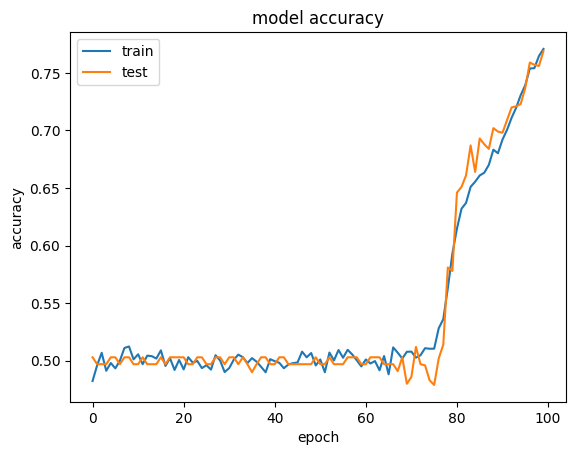

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
model.save('chatbot.keras')

In [ ]:
model.load_weights('chatbot.keras')

In [ ]:
predicted_results=model.predict(([inputs_test,queries_test]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
test_data

[(['Mary',
   'got',
   'the',
   'milk',
   'there',
   '.',
   'John',
   'moved',
   'to',
   'the',
   'bedroom',
   '.'],
  ['Is', 'John', 'in', 'the', 'kitchen', '?'],
  'no'),
 (['Mary',
   'got',
   'the',
   'milk',
   'there',
   '.',
   'John',
   'moved',
   'to',
   'the',
   'bedroom',
   '.',
   'Mary',
   'discarded',
   'the',
   'milk',
   '.',
   'John',
   'went',
   'to',
   'the',
   'garden',
   '.'],
  ['Is', 'John', 'in', 'the', 'kitchen', '?'],
  'no'),
 (['Mary',
   'got',
   'the',
   'milk',
   'there',
   '.',
   'John',
   'moved',
   'to',
   'the',
   'bedroom',
   '.',
   'Mary',
   'discarded',
   'the',
   'milk',
   '.',
   'John',
   'went',
   'to',
   'the',
   'garden',
   '.',
   'Daniel',
   'moved',
   'to',
   'the',
   'bedroom',
   '.',
   'Daniel',
   'went',
   'to',
   'the',
   'garden',
   '.'],
  ['Is', 'John', 'in', 'the', 'garden', '?'],
  'yes'),
 (['Mary',
   'got',
   'the',
   'milk',
   'there',
   '.',
   'John',
   'moved',


In [ ]:
test_data[0][0]

['Mary',
 'got',
 'the',
 'milk',
 'there',
 '.',
 'John',
 'moved',
 'to',
 'the',
 'bedroom',
 '.']

In [ ]:
predicted_results.shape

(1000, 43)

In [ ]:
val_max=np.argmax(predicted_results[0])

In [ ]:
for key,val in tokenizer.word_index.items():
  if val==val_max:
    k=key

In [ ]:
k

'yes'

In [ ]:
predicted_results[0][val_max]

np.float32(0.7223186)

In [ ]:
vocab

{'.',
 '?',
 'Daniel',
 'Is',
 'John',
 'Mary',
 'Sandra',
 'apple',
 'back',
 'bathroom',
 'bedroom',
 'discarded',
 'down',
 'dropped',
 'e',
 'football',
 'garden',
 'got',
 'grabbed',
 'hallway',
 'in',
 'journeyed',
 'kitchen',
 'left',
 'milk',
 'moved',
 'n',
 'no',
 'o',
 'office',
 'picked',
 'put',
 's',
 'the',
 'there',
 'to',
 'took',
 'travelled',
 'up',
 'went',
 'y',
 'yes'}

In [ ]:
my_story='John left the kitchen . Sandra dropped the football in the garden .'

In [ ]:
my_story.split()

['John',
 'left',
 'the',
 'kitchen',
 '.',
 'Sandra',
 'dropped',
 'the',
 'football',
 'in',
 'the',
 'garden',
 '.']

In [ ]:
my_question='Is the football in the garden ?'

In [ ]:
my_question.split()

['Is', 'the', 'football', 'in', 'the', 'garden', '?']

In [ ]:
my_data=[([my_story.split(),my_question.split(),'yes'])]

In [ ]:
my_data

[[['John',
   'left',
   'the',
   'kitchen',
   '.',
   'Sandra',
   'dropped',
   'the',
   'football',
   'in',
   'the',
   'garden',
   '.'],
  ['Is', 'the', 'football', 'in', 'the', 'garden', '?'],
  'yes']]

In [ ]:
my_story,my_ques,my_ans=vectorize_stories(my_data)

In [ ]:
my_ans

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
predicted_results=model.predict(([my_story,my_ques]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [ ]:
val_max=np.argmax(predicted_results[0])

In [ ]:
for key,value in tokenizer.word_index.items():
  if value==val_max:
    k=key

In [ ]:
k

'yes'

In [ ]:
predicted_results[0][val_max]

np.float32(0.8969449)